In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python is working!")

Python is working!


In [2]:
print("Pediatric Cancer Research Analysis")
print("This project looks at pediatric cancer disease burden compared to research attention.")

Pediatric Cancer Research Analysis
This project looks at pediatric cancer disease burden compared to research attention.


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/SAMPLE_INFO.tsv", sep="\t")

df.head()

,file_type,subject_name,sample_name,sample_type,file_size,attr_age_at_diagnosis,attr_diagnosis,attr_diagnosis_group,attr_ethnicity,attr_germline_sample,...,sj_embargo_date,sj_long_disease_name,sj_pipeline_name,sj_pipeline_version,sj_pmid_accessions,sj_pub_accessions,sj_publication_titles,target_name,tissue_type,file_id
0,BAM,SJ045720,SJNORM045720_G1,Germline,5102185802,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq40j9pPF37VKqPPpg7vbj
1,BAM,SJ045726,SJNORM045726_G1,Germline,7934104,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzx09gxqBZ7VYGFVYXP03
2,BAM,SJ045711,SJNORM045711_G1,Germline,7204704,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzzj9pV6XbVZKPKvXvgpQ
3,BAM,SJ045724,SJNORM045724_G1,Germline,6987427744,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpv8893Gqkf62kPKk6BVb4
4,BAM,SJ045716,SJNORM045716_G1,Germline,7323544,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq1009q68xf8ZzJGV242Q1


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percent Missing
attr_subtype_biomarkers,8125,5.121272


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())
df.info()

Number of duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 158652 entries, 0 to 158651
Data columns (total 44 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   file_type                        158652 non-null  str  
 1   subject_name                     158652 non-null  str  
 2   sample_name                      158652 non-null  str  
 3   sample_type                      158652 non-null  str  
 4   file_size                        158652 non-null  int64
 5   attr_age_at_diagnosis            158652 non-null  str  
 6   attr_diagnosis                   158652 non-null  str  
 7   attr_diagnosis_group             158652 non-null  str  
 8   attr_ethnicity                   158652 non-null  str  
 9   attr_germline_sample             158652 non-null  str  
 10  attr_inferred_strandedness       158652 non-null  str  
 11  attr_lab_strandedness            158652 non-null  str  
 12  attr_library_

### Cleaning Decisions

There were no duplicate rows in the dataset. Most columns did not contain missing values. The `attr_subtype_biomarkers` column had some missing values, so I kept them as missing rather than removing those rows because the missing information may still be useful for analysis. I also checked the data types and category values for inconsistencies.

In [6]:
cancer_counts = df["ped_cancer_diagnosis_category"].value_counts()

cancer_counts.head(15)

ped_cancer_diagnosis_category
Not Applicable                         96022
Lymphoblastic Leukemia                 16614
Myeloid Leukemia                        8491
High-grade Glioma                       4898
Medulloblastoma                         4016
Neuroblastoma                           3100
Ependymoma                              2489
Renal Tumors                            2474
Rhabdomyosarcoma                        2445
Osteosarcoma                            2341
Soft Tissue Tumors                      2007
Other Solid Tumors                      1879
Retinoblastoma                          1818
Endocrine and Neuroendocrine Tumors     1613
Glioneuronal and Neuronal Tumors        1132
Name: count, dtype: int64

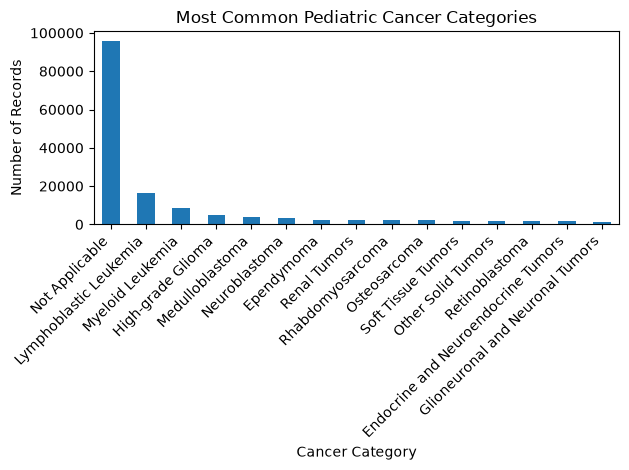

In [7]:
import matplotlib.pyplot as plt

cancer_counts.head(15).plot(kind="bar")

plt.title("Most Common Pediatric Cancer Categories")
plt.xlabel("Cancer Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

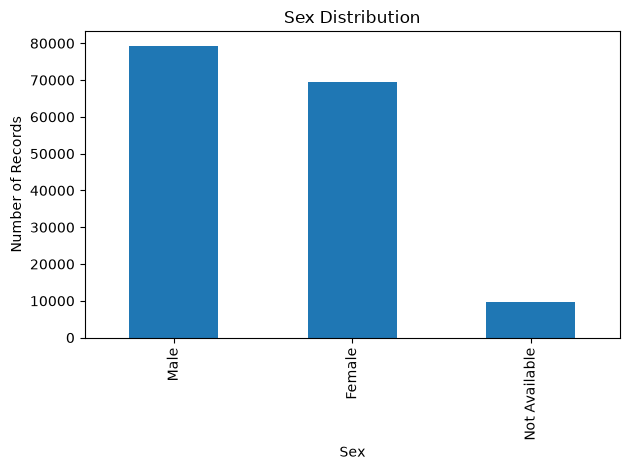

In [8]:
df["attr_sex"].value_counts().plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

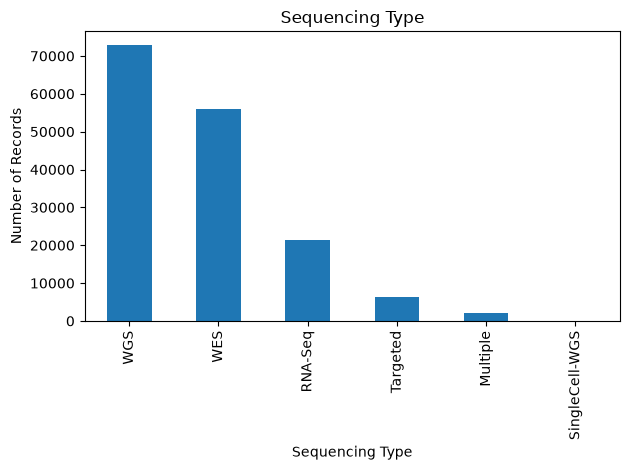

In [9]:
df["sequencing_type"].value_counts().plot(kind="bar")

plt.title("Sequencing Type")
plt.xlabel("Sequencing Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

The dataset contains 158,652 records and 44 variables. I found that the dataset includes several different pediatric cancer categories, with some categories having many more records than others. The dataset also contains information about patient characteristics, cancer diagnosis, sample type, and sequencing type. One concern is that a large number of records are labeled “Not Applicable” for some cancer classification variables, so I will need to decide how to handle these records when comparing cancer types. I am hoping to have more data by next week, as I am still wiating to gain access to several SEER databases. 

# Unit 5: Baseline Model

## 1. Data Pipeline

In [10]:
with open("../data/raw/seer.txt", "r") as file:
    seer_text = file.read()

print("SEER session file loaded successfully.")
print("Number of characters:", len(seer_text))

SEER session file loaded successfully.
Number of characters: 8622


### Pipeline Check

The SEER session file loaded successfully without errors. The file contains the settings for my SEER survival analysis, including the variables and survival intervals I plan to use. The actual SEER results will be added once they are exported from SEER*Stat.

In [11]:
with open("../data/raw/seer2.txt", "r") as file:
    seer2_text = file.read()

print("SEER 2 file loaded successfully!")
print("Number of characters:", len(seer2_text))

SEER 2 file loaded successfully!
Number of characters: 15332


In [12]:
print(seer2_text[:3000])

[Session]
Version=125
Type=Survival
Database=Incidence - SEER Research Limited-Field Data, 22 Registries (excl IL and MA), Nov 2023 Sub (2000-2021) - Linked To County Attributes - Time Dependent (1990-2022) Income/Rurality, 1969-2022 Counties
RateTable=U.S. by SES/geography/race (NHW,NHB,NHAIAN,NHAPI,HISP) 1992-2021, Ages 0-99, State-county (modeled by varied state-county-ses)
MatrixInterval=12,24,36,48,60

[Files]
1=seer\nov2023\distributed\yr1973_2021.sf1.cbf
Type1=1 (Case)
2=seer\nov2023\distributed\yr1973_2021.sf2.cbf
Type2=1 (Case)
3=seer\nov2023\distributed\yr1973_2021.sf3.cbf
Type3=1 (Case)
4=seer\nov2023\distributed\yr1973_2021.sf4.cbf
Type4=1 (Case)
5=seer\nov2023\distributed\yr1973_2021.sf5.cbf
Type5=1 (Case)
6=seer\nov2023\distributed\yr1973_2021.ct1.cbf
Type6=1 (Case)
7=seer\nov2023\distributed\yr1973_2021.ct2.cbf
Type7=1 (Case)
8=seer\nov2023\distributed\yr1973_2021.ct3.cbf
Type8=1 (Case)
9=seer\nov2023\distributed\yr1973_2021.ct4.cbf
Type9=1 (Case)
10=seer\nov2023\distrib

In [13]:
for line in seer2_text.splitlines():
    if "Var" in line:
        print(line)

[Var1]
[Var2]
Year Var~0=Year of diagnosis~192-221
Age Var~1=Age at diagnosis~0-99
Count Var~3=Count
Other Rate Var1~4=Race and origin recode (NHW, NHB, NHAIAN, NHAPI, Hispanic)~1-5,9
Begin Month Var~7=Month of diagnosis recode
Begin Year Var~8=Year of diagnosis
End Month Var~10=Month of follow-up recode
End Year Var~11=Year of follow-up recode
Vital Status Var~12=Vital status recode (study cutoff used)~1~0
Microscopic Confirmation Var~13=Diagnostic Confirmation~1-4
Tumor Behavior Var~15=Behavior code ICD-O-3~3
Record Sequence Var~16=Sequence number~0-1~0
Report Source Var~17=Type of reporting source~1-5,8
Other Rate Var2~18=Sex~1-2
Age In Years Var~19=Age at diagnosis
Age Calc Month Var~20=Month of diagnosis recode
Age Calc Year Var~21=Year of diagnosis
Rate Var~24=Expected rate
Person ID Vars~25=Patient ID
Record Order Var~27=Record number recode
Other Rate Var3~28=State~1-2,4-6,8-13,15-42,44-51,53-56
Other Rate Var4~29=County~1,3,5-7,9-17,19-21,23,25,27-29,31,33,35-37,39,41,43,45,47

### Second SEER File

I added a second SEER survival session to my project. I loaded the file successfully and reviewed the variables and settings included in the analysis. This session uses a larger SEER database with 22 registries and includes survival intervals up to 60 months.

I am keeping both SEER files so I can compare their settings and decide which one is more useful for my final analysis. These files contain the setup for the SEER survival analyses rather than the final results, so I will still need the numerical results before using SEER survival data in my baseline model.

In [14]:
print("First SEER file characters:", len(seer_text))
print("Second SEER file characters:", len(seer2_text))

First SEER file characters: 8622
Second SEER file characters: 15332


In [15]:
print("First file contains Relative Survival:",
      "Relative Survival" in seer_text)

print("Second file contains Relative Survival:",
      "Relative Survival" in seer2_text)

First file contains Relative Survival: True
Second file contains Relative Survival: True


In [16]:
print("Both SEER session files loaded successfully!")

Both SEER session files loaded successfully!


### Pipeline Check

Both SEER session files loaded successfully without errors. I was able to review the analysis settings and variables contained in each file. The second SEER session uses a larger registry database, while both files are set up for relative survival analysis. The SEER files are session files rather than final tabular results, so the next step is to obtain the numerical results needed for feature engineering and modeling.

### Update
I am having trouble coverting the SEER txt files to csv files, so i will continue working with the St. Judes sample info tsv file.

In [17]:
df = pd.read_csv("../data/raw/SAMPLE_INFO.tsv", sep="\t")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 158652
Columns: 44


,file_type,subject_name,sample_name,sample_type,file_size,attr_age_at_diagnosis,attr_diagnosis,attr_diagnosis_group,attr_ethnicity,attr_germline_sample,...,sj_embargo_date,sj_long_disease_name,sj_pipeline_name,sj_pipeline_version,sj_pmid_accessions,sj_pub_accessions,sj_publication_titles,target_name,tissue_type,file_id
0,BAM,SJ045720,SJNORM045720_G1,Germline,5102185802,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq40j9pPF37VKqPPpg7vbj
1,BAM,SJ045726,SJNORM045726_G1,Germline,7934104,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzx09gxqBZ7VYGFVYXP03
2,BAM,SJ045711,SJNORM045711_G1,Germline,7204704,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpzzj9pV6XbVZKPKvXvgpQ
3,BAM,SJ045724,SJNORM045724_G1,Germline,6987427744,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fpv8893Gqkf62kPKk6BVb4
4,BAM,SJ045716,SJNORM045716_G1,Germline,7323544,Not Available,Not Available,Not Applicable,Not Available,Not Applicable,...,Jan-15-2019,Not Applicable,DNA-Seq Standard,1.0.0,-,-,-,EXOME,normal,file-F9Fq1009q68xf8ZzJGV242Q1


In [18]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Duplicate rows remaining:", df_clean.duplicated().sum())

Original rows: 158652
Clean rows: 158652
Duplicate rows remaining: 0


In [19]:
missing = df_clean.isnull().sum()

missing[missing > 0]

attr_subtype_biomarkers    8125
dtype: int64

In [20]:
model_df = df_clean[[
    "ped_cancer_diagnosis_category",
    "attr_age_at_diagnosis",
    "attr_sex",
    "tissue_type",
    "sequencing_type"
]].copy()

model_df.head()

,ped_cancer_diagnosis_category,attr_age_at_diagnosis,attr_sex,tissue_type,sequencing_type
0,Not Applicable,Not Available,Not Available,normal,WES
1,Not Applicable,Not Available,Not Available,normal,WES
2,Not Applicable,Not Available,Not Available,normal,WES
3,Not Applicable,Not Available,Not Available,normal,WES
4,Not Applicable,Not Available,Not Available,normal,WES


In [21]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158652 entries, 0 to 158651
Data columns (total 5 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   ped_cancer_diagnosis_category  158652 non-null  str  
 1   attr_age_at_diagnosis          158652 non-null  str  
 2   attr_sex                       158652 non-null  str  
 3   tissue_type                    158652 non-null  str  
 4   sequencing_type                158652 non-null  str  
dtypes: str(5)
memory usage: 6.1 MB


In [22]:
model_df.isnull().sum()

ped_cancer_diagnosis_category    0
attr_age_at_diagnosis            0
attr_sex                         0
tissue_type                      0
sequencing_type                  0
dtype: int64

In [23]:
model_df["ped_cancer_diagnosis_category"].value_counts()

ped_cancer_diagnosis_category
Not Applicable                                    96022
Lymphoblastic Leukemia                            16614
Myeloid Leukemia                                   8491
High-grade Glioma                                  4898
Medulloblastoma                                    4016
Neuroblastoma                                      3100
Ependymoma                                         2489
Renal Tumors                                       2474
Rhabdomyosarcoma                                   2445
Osteosarcoma                                       2341
Soft Tissue Tumors                                 2007
Other Solid Tumors                                 1879
Retinoblastoma                                     1818
Endocrine and Neuroendocrine Tumors                1613
Glioneuronal and Neuronal Tumors                   1132
Ewings Sarcoma                                     1049
Atypical Teratoid/Rhabdoid Tumors                   849
Other Gliomas     

In [24]:
model_df = model_df[
    model_df["ped_cancer_diagnosis_category"] != "Not Applicable"
].copy()

print("Rows remaining:", len(model_df))

model_df["ped_cancer_diagnosis_category"].value_counts()

Rows remaining: 62630


ped_cancer_diagnosis_category
Lymphoblastic Leukemia                            16614
Myeloid Leukemia                                   8491
High-grade Glioma                                  4898
Medulloblastoma                                    4016
Neuroblastoma                                      3100
Ependymoma                                         2489
Renal Tumors                                       2474
Rhabdomyosarcoma                                   2445
Osteosarcoma                                       2341
Soft Tissue Tumors                                 2007
Other Solid Tumors                                 1879
Retinoblastoma                                     1818
Endocrine and Neuroendocrine Tumors                1613
Glioneuronal and Neuronal Tumors                   1132
Ewings Sarcoma                                     1049
Atypical Teratoid/Rhabdoid Tumors                   849
Other Gliomas                                       830
Other Hematopoieti

In [25]:
for column in [
    "attr_age_at_diagnosis",
    "attr_sex",
    "tissue_type",
    "sequencing_type"
]:
    print("\nCOLUMN:", column)
    print(model_df[column].value_counts().head(20))


COLUMN: attr_age_at_diagnosis
attr_age_at_diagnosis
Not Available    7168
2.00              837
3.00              697
4.00              498
1.33              464
6.00              459
1.83              425
1.92              396
2.92              381
1.58              381
2.50              377
14.00             377
1.42              364
5.00              354
2.08              352
12.00             342
3.83              341
0.75              339
1.25              335
2.67              333
Name: count, dtype: int64

COLUMN: attr_sex
attr_sex
Male             32427
Female           26837
Not Available     3366
Name: count, dtype: int64

COLUMN: tissue_type
tissue_type
tumor    62630
Name: count, dtype: int64

COLUMN: sequencing_type
sequencing_type
WES         22000
RNA-Seq     21391
WGS         17263
Multiple     1976
Name: count, dtype: int64


### Target Variable Cleaning

For my preliminary baseline model, I am using pediatric cancer diagnosis category as the target variable. I found that 96,022 records were labeled "Not Applicable" for this variable. Since "Not Applicable" is not an actual pediatric cancer category, I removed these records from the modeling dataset. I kept the original cleaned dataset unchanged so these records are still available for later analysis.

In [26]:
model_df["attr_age_at_diagnosis"] = pd.to_numeric(
    model_df["attr_age_at_diagnosis"],
    errors="coerce"
)

print("Missing ages:", model_df["attr_age_at_diagnosis"].isnull().sum())

Missing ages: 7168


In [27]:
median_age = model_df["attr_age_at_diagnosis"].median()

model_df["attr_age_at_diagnosis"] = (
    model_df["attr_age_at_diagnosis"].fillna(median_age)
)

print("Median age:", median_age)
print("Missing ages remaining:",
      model_df["attr_age_at_diagnosis"].isnull().sum())

Median age: 7.22
Missing ages remaining: 0


In [28]:
model_df = model_df.drop(columns=["tissue_type"])

model_df.head()

,ped_cancer_diagnosis_category,attr_age_at_diagnosis,attr_sex,sequencing_type
26622,CNS Germ Cell Tumors,10.75,Female,WGS
26623,CNS Germ Cell Tumors,10.75,Female,WGS
26625,Lymphoblastic Leukemia,13.92,Male,WGS
26626,Lymphoblastic Leukemia,13.92,Male,WGS
26629,Lymphoblastic Leukemia,17.92,Male,WGS


### Cleaning Decisions for Baseline Model

Before creating my baseline model, I cleaned the variables I planned to use. The age at diagnosis column contained "Not Available" values, so I converted the valid ages to numerical values and filled the missing ages with the median age. I kept "Not Available" as a category for sex instead of removing those records. I removed tissue type from the model because all of the remaining records were labeled as tumor, so this variable would not help distinguish between pediatric cancer categories.

In [29]:
y = model_df["ped_cancer_diagnosis_category"]

In [30]:
X = model_df[[
    "attr_age_at_diagnosis",
    "attr_sex",
    "sequencing_type"
]].copy()

X.head()

,attr_age_at_diagnosis,attr_sex,sequencing_type
26622,10.75,Female,WGS
26623,10.75,Female,WGS
26625,13.92,Male,WGS
26626,13.92,Male,WGS
26629,17.92,Male,WGS


In [31]:
X = pd.get_dummies(
    X,
    columns=["attr_sex", "sequencing_type"],
    drop_first=True
)

X.head()

,attr_age_at_diagnosis,attr_sex_Male,attr_sex_Not Available,sequencing_type_RNA-Seq,sequencing_type_WES,sequencing_type_WGS
26622,10.75,False,False,False,False,True
26623,10.75,False,False,False,False,True
26625,13.92,True,False,False,False,True
26626,13.92,True,False,False,False,True
26629,17.92,True,False,False,False,True


In [32]:
print(X.shape)
print(X.dtypes)

(62630, 6)
attr_age_at_diagnosis      float64
attr_sex_Male                 bool
attr_sex_Not Available        bool
sequencing_type_RNA-Seq       bool
sequencing_type_WES           bool
sequencing_type_WGS           bool
dtype: object


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 50104
Testing rows: 12526


### Feature Engineering Decisions

For my baseline model, I used age at diagnosis, sex, and sequencing type as my features. I converted sex and sequencing type into dummy variables so they could be used by the model. Age at diagnosis was kept as a numerical variable. I did not scale the variables because I plan to use a decision tree for my baseline model, which does not require feature scaling. I used an 80/20 train-test split so that most of the data could be used to train the model while keeping a separate portion for evaluation.

## Baseline Model

In [34]:
from sklearn.tree import DecisionTreeClassifier

baseline_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline model trained successfully!")

Baseline model trained successfully!


### Model Choice

I chose a decision tree classifier for my baseline model because my target variable, pediatric cancer diagnosis category, contains multiple categories. A decision tree can work with both numerical and dummy variables and does not require the numerical features to be scaled. I limited the tree to a maximum depth of 5 to keep the baseline model simple and reduce the chance of overfitting.

This model is a preliminary baseline for my project. It does not directly answer my final research question about disease burden and research attention yet, but it allows me to test my data pipeline and establish a starting point for later models.

## Baseline Model Evaluation

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.275
Precision: 0.212
Recall: 0.275
F1 Score: 0.152


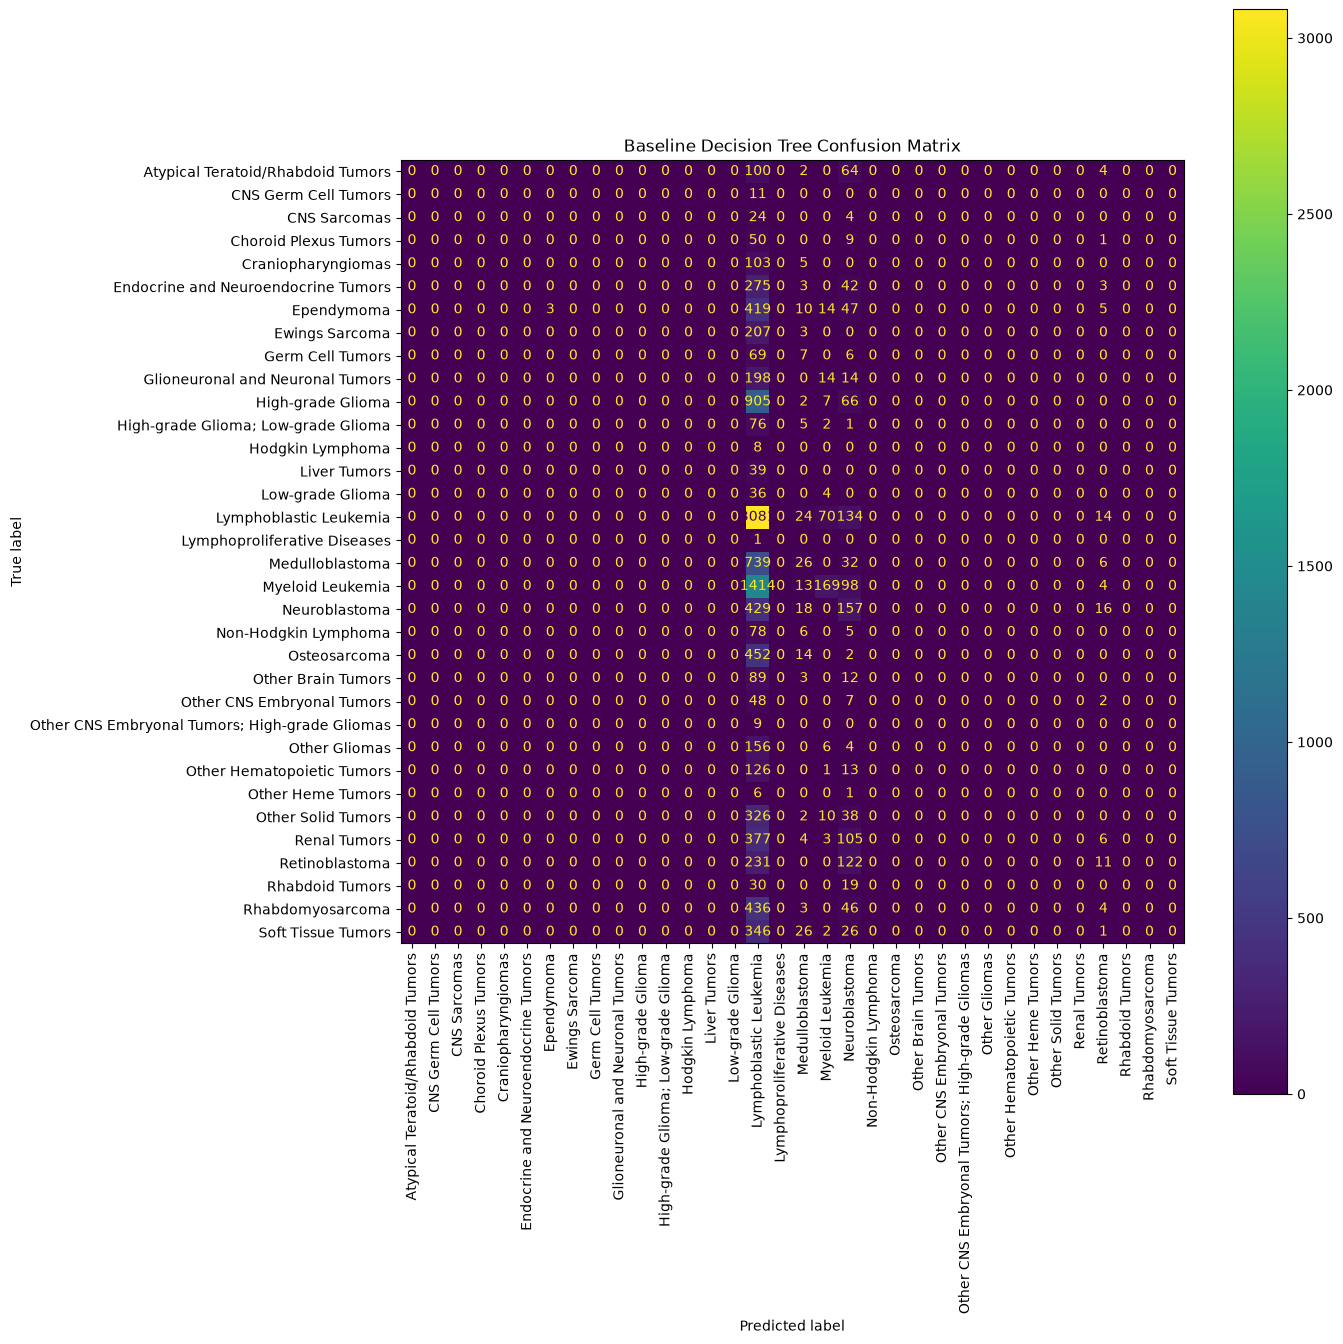

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Baseline Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                                                precision    recall  f1-score   support

             Atypical Teratoid/Rhabdoid Tumors       0.00      0.00      0.00       170
                          CNS Germ Cell Tumors       0.00      0.00      0.00        11
                                  CNS Sarcomas       0.00      0.00      0.00        28
                         Choroid Plexus Tumors       0.00      0.00      0.00        60
                            Craniopharyngiomas       0.00      0.00      0.00       108
           Endocrine and Neuroendocrine Tumors       0.00      0.00      0.00       323
                                    Ependymoma       1.00      0.01      0.01       498
                                Ewings Sarcoma       0.00      0.00      0.00       210
                              Germ Cell Tumors       0.00      0.00      0.00        82
              Glioneuronal and Neuronal Tumors       0.00      0.00      0.00       226
                             Hi

### Evaluation Interpretation

The baseline decision tree had an accuracy of 27.5%, precision of 21.2%, recall of 27.5%, and an F1 score of 15.2%. The confusion matrix shows that the model predicts a small number of the larger cancer categories much more often than the less common categories. Many of the smaller cancer categories are rarely or never predicted correctly.

This suggests that class imbalance is affecting the model's performance. Some cancer categories have thousands of records, while others have fewer than 100. The features used in this baseline model—age at diagnosis, sex, and sequencing type—also may not provide enough information to clearly distinguish between all of the cancer categories. Overall, this model gives me a useful starting point, but there is significant room for improvement.

## Preliminary Findings

My baseline model used age at diagnosis, sex, and sequencing type to predict pediatric cancer diagnosis category. The decision tree achieved an accuracy of 27.5%, precision of 21.2%, recall of 27.5%, and an F1 score of 15.2%. Overall, these results show that the selected features are not enough to accurately distinguish between the different pediatric cancer categories.

The confusion matrix also shows that the model tends to predict a small number of the larger cancer categories while rarely predicting many of the smaller categories. This reflects an important limitation in the dataset because the cancer categories are very unevenly represented. For example, some categories have thousands of records, while others have fewer than 100.

This baseline does not directly answer my final research question about disease burden and research attention. Instead, it establishes a working modeling pipeline and identifies class imbalance as an issue to address. In the next stages of the project, I plan to incorporate disease burden and research attention data to make a more direct comparison.

### Reproducibility Check

I restarted the kernel and ran the notebook from beginning to end. The full data pipeline, feature engineering, baseline model, and evaluation ran successfully without errors.